# 04. DistilBERT 파인튜닝

`distilbert-base-uncased`를 Steam 리뷰 긍/부정 분류로 파인튜닝한다.

- 파인튜닝 표준 권장치인 **3에폭**으로 학습하되, 에폭마다 val을 평가해 **최적 에폭의 모델을 자동 선택**한다 (`load_best_model_at_end`).
- 튜닝 대상 하이퍼파라미터는 아래 전용 셀에 모아 두었다.

산출물: `models/distilbert/` (모델+토크나이저), `models/distilbert/metrics.json`

In [7]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from sklearn.metrics import accuracy_score, f1_score
from src.config import MODEL_DIR, OUTPUT_DIR, DATA_DIR

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 하이퍼파라미터

튜닝할 때는 이 셀만 수정하면 된다.

| 변수 | 의미 | 튜닝 가이드 |
|---|---|---|
| `EPOCHS` | 파인튜닝 에폭 | BERT 계열 권장 2~4, val 최적 에폭 자동 선택 |
| `LR` | 학습률 | 2e-5 ~ 5e-5 범위 탐색 |
| `TRAIN_MAX_LEN` | 토큰 최대 길이 | 128 초과 시 16GB MPS에서 OOM 주의 |
| `BATCH_SIZE` × `GRAD_ACCUM` | 유효 배치 = 곱 | 배치를 키우는 대신 누적으로 메모리 절약 |
| `WEIGHT_DECAY` | L2 정규화 | 과적합 시 0.01~0.1 |

In [8]:
BASE_MODEL = "distilbert-base-uncased"

# ── 학습 하이퍼파라미터 ──────────────────────────────
EPOCHS = 3            # 파인튜닝 에폭 (val 기준 최적 에폭 자동 선택)
LR = 5e-5             # AdamW 학습률
WEIGHT_DECAY = 0.0    # L2 정규화

# ── 입력/메모리 하이퍼파라미터 ───────────────────────
TRAIN_MAX_LEN = 128   # 토큰 최대 길이 (16GB MPS OOM 방지)
BATCH_SIZE = 8        # 디바이스당 학습 배치
GRAD_ACCUM = 2        # gradient accumulation (유효 배치 = 8×2 = 16)
EVAL_BATCH_SIZE = 16

In [9]:
tok = AutoTokenizer.from_pretrained(BASE_MODEL)

def load(split):
    return Dataset.from_pandas(pd.read_csv(DATA_DIR / f"{split}.csv"))

def enc(b):
    return tok(b["text"], truncation=True, max_length=TRAIN_MAX_LEN)

ds = {s: load(s).map(enc, batched=True) for s in ["train", "val", "test"]}
print({s: len(d) for s, d in ds.items()})

Map: 100%|██████████| 1219/1219 [00:00<00:00, 14594.73 examples/s]

{'train': 5686, 'val': 1218, 'test': 1219}


In [10]:
model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2)

def metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {"accuracy": accuracy_score(p.label_ids, preds),
            "f1": f1_score(p.label_ids, preds)}

out = MODEL_DIR / "distilbert"
args = TrainingArguments(
    output_dir=str(out), num_train_epochs=EPOCHS,
    learning_rate=LR, weight_decay=WEIGHT_DECAY,
    per_device_train_batch_size=BATCH_SIZE, gradient_accumulation_steps=GRAD_ACCUM,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    eval_strategy="epoch",
    # val F1 최적 에폭의 모델을 학습 종료 시 자동 복원
    save_strategy="epoch", save_total_limit=1,
    load_best_model_at_end=True, metric_for_best_model="eval_f1",
    report_to=[])
trainer = Trainer(model=model, args=args,
                  train_dataset=ds["train"], eval_dataset=ds["val"],
                  data_collator=DataCollatorWithPadding(tok),
                  compute_metrics=metrics)
trainer.train()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5994.86it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.337357,0.847291,0.840206
2,0.724835,0.466310,0.860427,0.853448
3,0.289001,0.614564,0.866174,0.867372


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.96it/s]
/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.91it/s]
/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.30it/s]


TrainOutput(global_step=1068, training_loss=0.48498106985056444, metrics={'train_runtime': 523.3312, 'train_samples_per_second': 32.595, 'train_steps_per_second': 2.041, 'total_flos': 541764753062688.0, 'train_loss': 0.48498106985056444, 'epoch': 3.0})

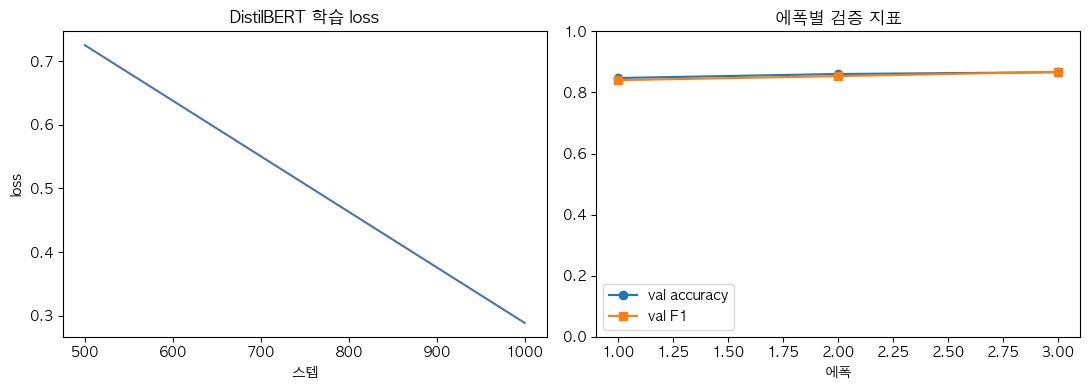

In [11]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

logs = trainer.state.log_history
train_steps = [(l["step"], l["loss"]) for l in logs if "loss" in l]
eval_logs = [l for l in logs if "eval_accuracy" in l]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(*zip(*train_steps), color="#4c72b0")
ax1.set_title("DistilBERT 학습 loss")
ax1.set_xlabel("스텝")
ax1.set_ylabel("loss")

epochs = [l["epoch"] for l in eval_logs]
ax2.plot(epochs, [l["eval_accuracy"] for l in eval_logs], "o-", label="val accuracy")
ax2.plot(epochs, [l["eval_f1"] for l in eval_logs], "s-", label="val F1")
ax2.set_title("에폭별 검증 지표")
ax2.set_xlabel("에폭")
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04_distilbert_loss_metrics_v2.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
import shutil

test_metrics = trainer.evaluate(ds["test"])
out.mkdir(parents=True, exist_ok=True)
model.save_pretrained(out)
tok.save_pretrained(out)
result = {"accuracy": test_metrics["eval_accuracy"], "f1": test_metrics["eval_f1"]}
(out / "metrics.json").write_text(json.dumps(result, indent=2))

# 중간 체크포인트 정리 (최종 모델만 유지, ~250MB 절약)
for ckpt in out.glob("checkpoint-*"):
    shutil.rmtree(ckpt)

print("DistilBERT test:", result)

/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.289001,0.636832,3,0.860541,0.862013


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.09it/s]

DistilBERT test: {'accuracy': 0.8605414273995078, 'f1': 0.862012987012987}


/Users/gomuseo/Desktop/Python/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


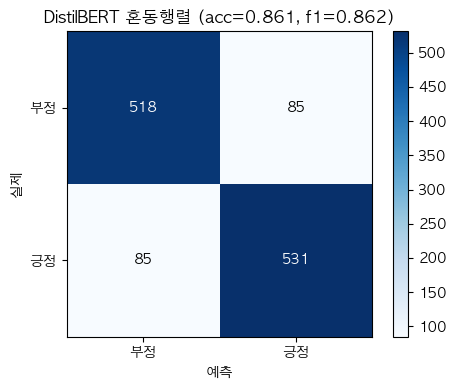

In [13]:
from sklearn.metrics import confusion_matrix

pred_out = trainer.predict(ds["test"])
preds = np.argmax(pred_out.predictions, axis=1)
cm = confusion_matrix(pred_out.label_ids, preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["부정", "긍정"])
ax.set_yticks([0, 1], ["부정", "긍정"])
ax.set_xlabel("예측")
ax.set_ylabel("실제")
ax.set_title(f"DistilBERT 혼동행렬 (acc={result['accuracy']:.3f}, f1={result['f1']:.3f})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04_distilbert_confusion_v2.png", dpi=150, bbox_inches="tight")
plt.show()